In [1]:
import numpy as np
from simple_model import SimpleCNN
from dataset import get_dataloader
import torch
import torch.optim as optim
import torch.nn as nn
from torchvision.transforms import v2

import copy
import json
import os

In [2]:
# _____________________ Device configuration _________________________
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
# ____________________________________________________
# Hyperparameters — all in one place for easy reference
# ____________________________________________________
NUM_EPOCHS    = 30
BATCH_SIZE    = 64
LEARNING_RATE = 0.001
WEIGHT_DECAY  = 0.0005
NUM_CLASSES   = 10  # CIFAR-10 always has 10 classes

# cutmix (combine two images transformation)
cutmix = v2.CutMix(num_classes=10, alpha=1.0)
CUTMIX_PROB = 0.5

In [4]:
# ____________________________________________________
# Experiment settings
# ____________________________________________________
PERCENTAGES = [0.1, 0.25, 0.50, 1.0]

# _____________________________________________________
# List your combinations here
# make a new list variable for every combinations group (ones, twos, threes, fours, fives, smart)
# then assign this list to COMBINATIONS variable
# e.g: COMBINATIONS = ONES_COMBINATIONS
# _____________________________________________________
#ones combinations
ONES_COMBINATIONS = [
    'none',
    'none_cutmix',
    'flip',
    'rotation_deg_15',
    'rotation_deg_30',
    'rotation_deg_90',
    'color_0.2',
    'color_0.3',
    'crop'
]

#two combinations
TWO_COMBINATIONS = [
    'none',
    'crop_cutmix',
    'flip_rotation',
    'flip_crop',
    'flip_cutmix',
    'flip_color',
    'rotation_color',
    'rotation_crop',
    'rotation_deg_15_cutmix',
    'color_0.3_cutmix',
    'color_crop',
]

#three combinations
#write here:
THREE_COMBINATIONS = [
    'none',
    'rotation_crop_cutmix',
    'rotation_color_cutmix',
    'rotation_color_crop',
    'flip_color_cutmix',
    'flip_rotation_cutmix',
    'flip_crop_cutmix',
    'flip_color_crop',
    'flip_rotation_crop',
    'flip_rotation_color',
    'color_crop_cutmix',
]
#four & five combinations
#write here:
FOUR_AND_FIVE_COMBINATIONS = [
    'none',
    'flip_rotation_crop_cutmix',
    'flip_color_crop_cutmix',
    'rotation_color_crop_cutmix',
    'flip_rotation_color_cutmix',
    'flip_rotation_color_crop',
    'flip_rotation_color_crop_cutmix',
]

SMART_COMBINATIONS = [
    'none',
    'auto_augment',
]

#COMBINATIONS = ONES_COMBINATIONS
# COMBINATIONS = TWO_COMBINATIONS
# COMBINATIONS = THREE_COMBINATIONS
# COMBINATIONS = FOUR_AND_FIVE_COMBINATIONS
COMBINATIONS = SMART_COMBINATIONS

In [5]:
# ____________________________________________________
# Training & Validation Functions
# ____________________________________________________
def train_epoch(model, train_loader, loss_function, optimizer, device, use_cutmix=False):
    """
    Performs a single training epoch.

    Args:
        model (torch.nn.Module): The neural network model to train.
        train_loader (torch.utils.data.DataLoader): The DataLoader for the training data.
        loss_function (callable): The loss function.
        optimizer (torch.optim.Optimizer): The optimizer.
        device (torch.device): The device (CPU or GPU) to perform training on.

    Returns:
        float: The average training loss for the epoch.
    """
    # Set the model to training mode
    model.train()
    running_loss = 0.0
    # Iterate over batches of data in the training loader
    for images, labels in train_loader:
        # Move images and labels to the specified device
        images, labels = images.to(device), labels.to(device)

        #apply cutmix (mixing two images) if required:
        if use_cutmix and np.random.rand() < 0.5:
            images, labels = cutmix(images, labels)

        # Clear the gradients of all optimized variables
        optimizer.zero_grad()

        # Perform a forward pass to get model outputs
        outputs = model(images)

        # Calculate the loss
        loss = loss_function(outputs, labels)

        # Perform a backward pass to compute gradients
        loss.backward()

        # Update the model parameters
        optimizer.step()

        # Accumulate the training loss for the batch
        running_loss += loss.item() * images.size(0)

    # Calculate and return the average training loss for the epoch
    epoch_loss = running_loss / len(train_loader.dataset)
    return epoch_loss

def validate_epoch(model, val_loader, loss_function, device):
    """
    Performs a single validation epoch.

    Args:
        model (torch.nn.Module): The neural network model to validate.
        val_loader (torch.utils.data.DataLoader): The DataLoader for the validation data.
        loss_function (callable): The loss function.
        device (torch.device): The device (CPU or GPU) to perform validation on.

    Returns:
        tuple: A tuple containing the average validation loss and validation accuracy.
    """
    # Set the model to evaluation mode
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    ### START CODE HERE ###

    # Disable gradient calculations for validation
    with torch.no_grad():

    ### END CODE HERE ###

        # Iterate over batches of data in the validation loader
        for images, labels in val_loader:
            # Move images and labels to the specified device
            images, labels = images.to(device), labels.to(device)

            ### START CODE HERE ###

            # Perform a forward pass to get model outputs
            outputs = model(images)

            # Calculate the validation loss for the batch
            val_loss = loss_function(outputs, labels)

            # Accumulate the validation loss
            running_val_loss += val_loss.item()

            # Get the predicted class labels
            _, predicted = torch.max(outputs, dim=1)

            ### END CODE HERE ###

            # Update the total number of samples
            total += labels.size(0)

            # Update the number of correct predictions
            correct += (predicted == labels).sum().item()


    # Calculate the average validation loss and accuracy for the epoch
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_accuracy = 100.0 * correct / total

    return epoch_val_loss, epoch_accuracy

def training_loop(model, train_loader, val_loader, loss_function, optimizer, num_epochs, device, use_cutmix = False):
    """
    Trains and validates a PyTorch neural network model.

    Args:
        model (torch.nn.Module): The model to be trained.
        train_loader (torch.utils.data.DataLoader): DataLoader for the training set.
        val_loader (torch.utils.data.DataLoader): DataLoader for the validation set.
        loss_function (callable): The loss function.
        optimizer (torch.optim.Optimizer): The optimization algorithm.
        num_epochs (int): The total number of epochs to train for.
        device (torch.device): The device (e.g., 'cuda' or 'cpu') to run training on.

    Returns:
        tuple: A tuple containing the best trained model and a list of metrics
               (train_losses, val_losses, val_accuracies).
    """
    # Move the model to the specified device (CPU or GPU)
    model.to(device)

    # Initialize variables to track the best performing model
    best_val_accuracy = 0.0
    best_model_state = None
    best_epoch = 0

    # Initialize lists to store training and validation metrics
    train_losses, val_losses, val_accuracies = [], [], []

    print("--- Training Started ---")

    # Loop over the specified number of epochs
    for epoch in range(num_epochs):
        # Perform one epoch of training
        epoch_loss = train_epoch(model, train_loader, loss_function, optimizer, device, use_cutmix)
        train_losses.append(epoch_loss)

        # Perform one epoch of validation
        epoch_val_loss, epoch_accuracy = validate_epoch(model, val_loader, loss_function, device)
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_accuracy)

        # Print the metrics for the current epoch
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {epoch_accuracy:.2f}%")

        # Check if the current model is the best one so far
        if epoch_accuracy > best_val_accuracy:
            best_val_accuracy = epoch_accuracy
            best_epoch = epoch + 1
            # Save the state of the best model in memory
            best_model_state = copy.deepcopy(model.state_dict())

    print("--- Finished Training ---")

    # Load the best model weights before returning
    if best_model_state:
        print(f"\n--- Returning best model with {best_val_accuracy:.2f}% validation accuracy, achieved at epoch {best_epoch} ---")
        model.load_state_dict(best_model_state)

    # Consolidate all metrics into a single list
    metrics = [train_losses, val_losses, val_accuracies]

    # Return the trained model and the collected metrics
    return model, metrics


In [6]:
def run_experiment(percentage, augmentation_combo_name):
    """
    Runs one complete experiment.

    Args:
        percentage:               0.10, 0.25, 0.50, or 1.0
        augmentation combo_name: 'none','flip','flip_rotation',
                                 'flip_rotation_color',
                                 'flip_rotation_color_crop','full'

    Returns:
        final accuracy (float) , metrics (list)
    """
    print(f"\n{'='*50}")
    print(f"Experiment: {percentage*100:.0f}% data, {augmentation_combo_name}")
    print(f"{'='*50}")

    #check whether cutmix exists or not
    use_cutmix = 'cutmix' in augmentation_combo_name
    base_combo_name = augmentation_combo_name.replace('_cutmix', '')

    # Get data
    train_loader, test_loader = get_dataloader(
        percentage,
        batch_size=BATCH_SIZE,
        augmentation_combo_name= base_combo_name
        # augmentation_combo_name=augmentation_combo_name,
    )

    # model for each experiment
    model = SimpleCNN(num_classes=NUM_CLASSES)

    # Loss and optimizer
    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    # Train
    trained_model, metrics = training_loop(
        model=model,
        train_loader=train_loader,
        val_loader=test_loader,
        loss_function=loss_function,
        optimizer=optimizer,
        num_epochs=NUM_EPOCHS,
        device=device,
        use_cutmix=use_cutmix
    )

    # Final accuracy = best accuracy achieved
    best_accuracy = max(metrics[2])
    print(f"\nFinal Best Accuracy: {best_accuracy:.2f}%")

    return best_accuracy, metrics


Experiment: 10% data, none
Training on 5000 images (10% of training data)
Testing on  10000 images (always full test set)
Train batches: 79
Test batches:  157
--- Training Started ---
Epoch [1/30], Train Loss: 1.8811, Val Loss: 0.0260, Val Accuracy: 36.37%
Epoch [2/30], Train Loss: 1.5460, Val Loss: 0.0226, Val Accuracy: 46.42%
Epoch [3/30], Train Loss: 1.3778, Val Loss: 0.0206, Val Accuracy: 52.12%
Epoch [4/30], Train Loss: 1.2904, Val Loss: 0.0237, Val Accuracy: 47.74%
Epoch [5/30], Train Loss: 1.2140, Val Loss: 0.0196, Val Accuracy: 56.08%
Epoch [6/30], Train Loss: 1.0799, Val Loss: 0.0191, Val Accuracy: 57.56%
Epoch [7/30], Train Loss: 1.0021, Val Loss: 0.0195, Val Accuracy: 56.08%
Epoch [8/30], Train Loss: 0.9354, Val Loss: 0.0178, Val Accuracy: 60.47%
Epoch [9/30], Train Loss: 0.8576, Val Loss: 0.0186, Val Accuracy: 58.53%
Epoch [10/30], Train Loss: 0.7824, Val Loss: 0.0182, Val Accuracy: 61.12%
Epoch [11/30], Train Loss: 0.7164, Val Loss: 0.0185, Val Accuracy: 60.00%
Epoch [12/

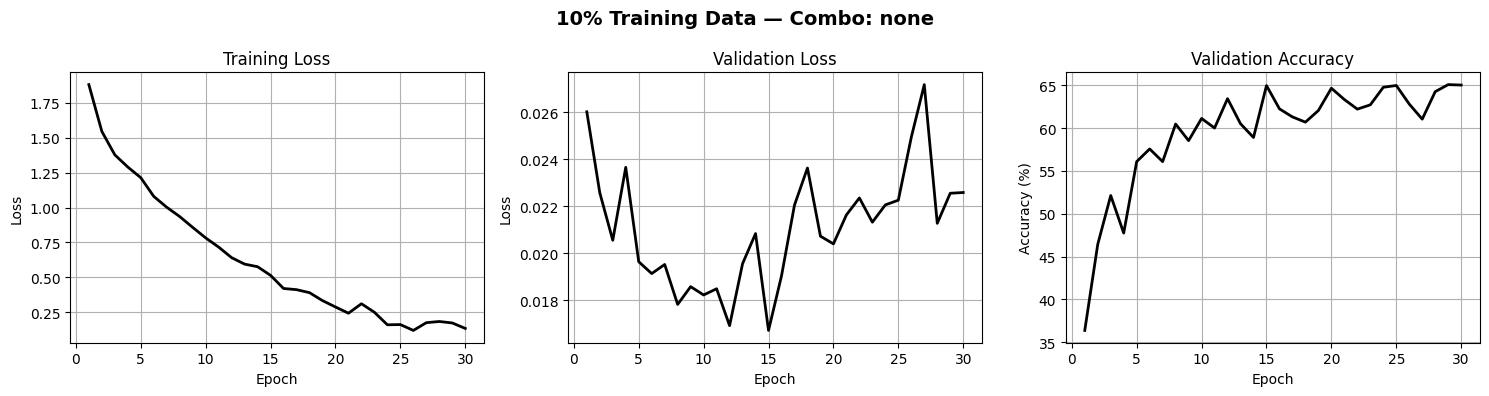


Experiment: 10% data, auto_augment
Training on 5000 images (10% of training data)
Testing on  10000 images (always full test set)
Train batches: 79
Test batches:  157
--- Training Started ---
Epoch [1/30], Train Loss: 2.1779, Val Loss: 0.0289, Val Accuracy: 33.13%
Epoch [2/30], Train Loss: 1.9119, Val Loss: 0.0252, Val Accuracy: 41.12%
Epoch [3/30], Train Loss: 1.7815, Val Loss: 0.0230, Val Accuracy: 48.15%
Epoch [4/30], Train Loss: 1.7009, Val Loss: 0.0232, Val Accuracy: 45.61%
Epoch [5/30], Train Loss: 1.6361, Val Loss: 0.0221, Val Accuracy: 48.98%
Epoch [6/30], Train Loss: 1.5805, Val Loss: 0.0208, Val Accuracy: 51.49%
Epoch [7/30], Train Loss: 1.4884, Val Loss: 0.0192, Val Accuracy: 55.78%
Epoch [8/30], Train Loss: 1.4648, Val Loss: 0.0193, Val Accuracy: 54.70%
Epoch [9/30], Train Loss: 1.4137, Val Loss: 0.0192, Val Accuracy: 56.95%
Epoch [10/30], Train Loss: 1.3894, Val Loss: 0.0198, Val Accuracy: 55.99%
Epoch [11/30], Train Loss: 1.3620, Val Loss: 0.0181, Val Accuracy: 58.21%
Ep

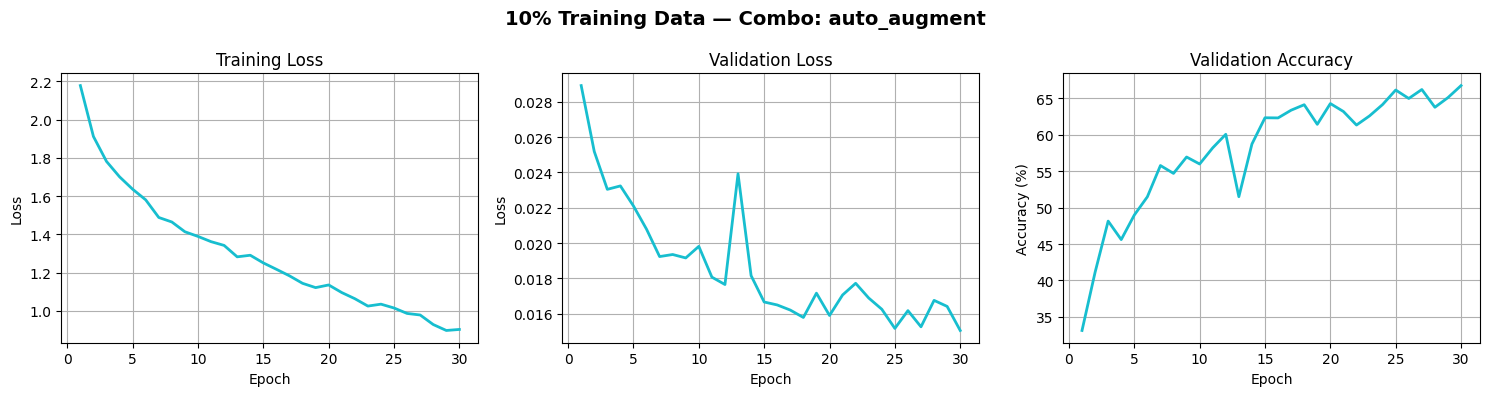


Experiment: 25% data, none
Training on 12500 images (25% of training data)
Testing on  10000 images (always full test set)
Train batches: 196
Test batches:  157
--- Training Started ---
Epoch [1/30], Train Loss: 1.6630, Val Loss: 0.0207, Val Accuracy: 52.05%
Epoch [2/30], Train Loss: 1.3090, Val Loss: 0.0186, Val Accuracy: 56.80%
Epoch [3/30], Train Loss: 1.1629, Val Loss: 0.0170, Val Accuracy: 61.34%
Epoch [4/30], Train Loss: 1.0386, Val Loss: 0.0163, Val Accuracy: 63.08%
Epoch [5/30], Train Loss: 0.9615, Val Loss: 0.0146, Val Accuracy: 66.66%
Epoch [6/30], Train Loss: 0.8844, Val Loss: 0.0144, Val Accuracy: 67.71%
Epoch [7/30], Train Loss: 0.8134, Val Loss: 0.0149, Val Accuracy: 67.32%
Epoch [8/30], Train Loss: 0.7549, Val Loss: 0.0135, Val Accuracy: 69.93%
Epoch [9/30], Train Loss: 0.7115, Val Loss: 0.0147, Val Accuracy: 68.30%
Epoch [10/30], Train Loss: 0.6529, Val Loss: 0.0133, Val Accuracy: 70.36%
Epoch [11/30], Train Loss: 0.5900, Val Loss: 0.0149, Val Accuracy: 67.93%
Epoch [1

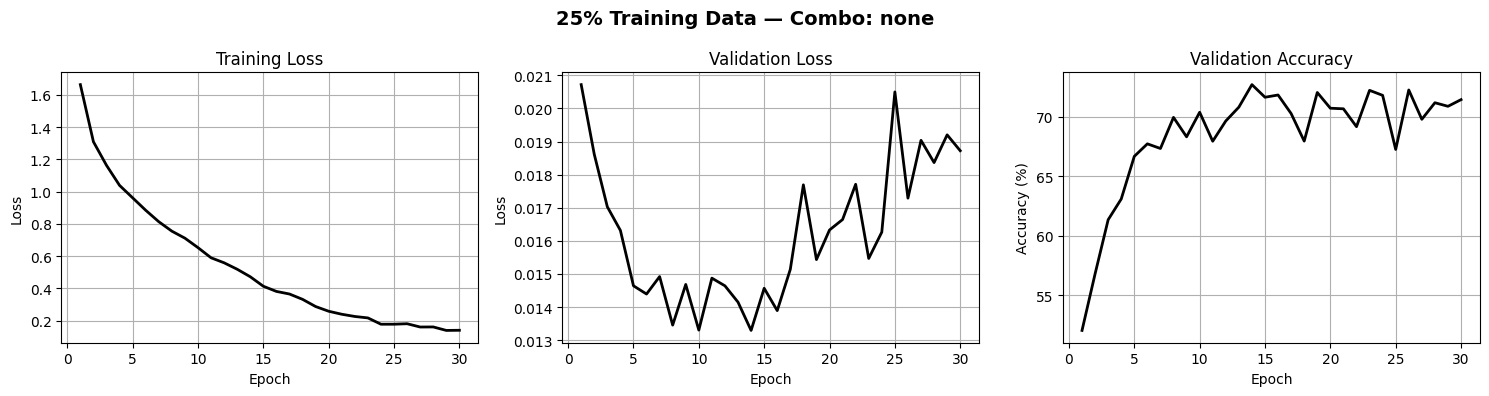


Experiment: 25% data, auto_augment
Training on 12500 images (25% of training data)
Testing on  10000 images (always full test set)
Train batches: 196
Test batches:  157
--- Training Started ---
Epoch [1/30], Train Loss: 1.9970, Val Loss: 0.0243, Val Accuracy: 43.01%
Epoch [2/30], Train Loss: 1.7070, Val Loss: 0.0205, Val Accuracy: 53.11%
Epoch [3/30], Train Loss: 1.5684, Val Loss: 0.0192, Val Accuracy: 58.07%
Epoch [4/30], Train Loss: 1.4555, Val Loss: 0.0172, Val Accuracy: 60.83%
Epoch [5/30], Train Loss: 1.3851, Val Loss: 0.0171, Val Accuracy: 61.09%
Epoch [6/30], Train Loss: 1.3338, Val Loss: 0.0187, Val Accuracy: 56.45%
Epoch [7/30], Train Loss: 1.2872, Val Loss: 0.0156, Val Accuracy: 64.34%
Epoch [8/30], Train Loss: 1.2636, Val Loss: 0.0153, Val Accuracy: 65.50%
Epoch [9/30], Train Loss: 1.2157, Val Loss: 0.0158, Val Accuracy: 64.43%
Epoch [10/30], Train Loss: 1.1890, Val Loss: 0.0147, Val Accuracy: 66.07%
Epoch [11/30], Train Loss: 1.1575, Val Loss: 0.0145, Val Accuracy: 66.85%


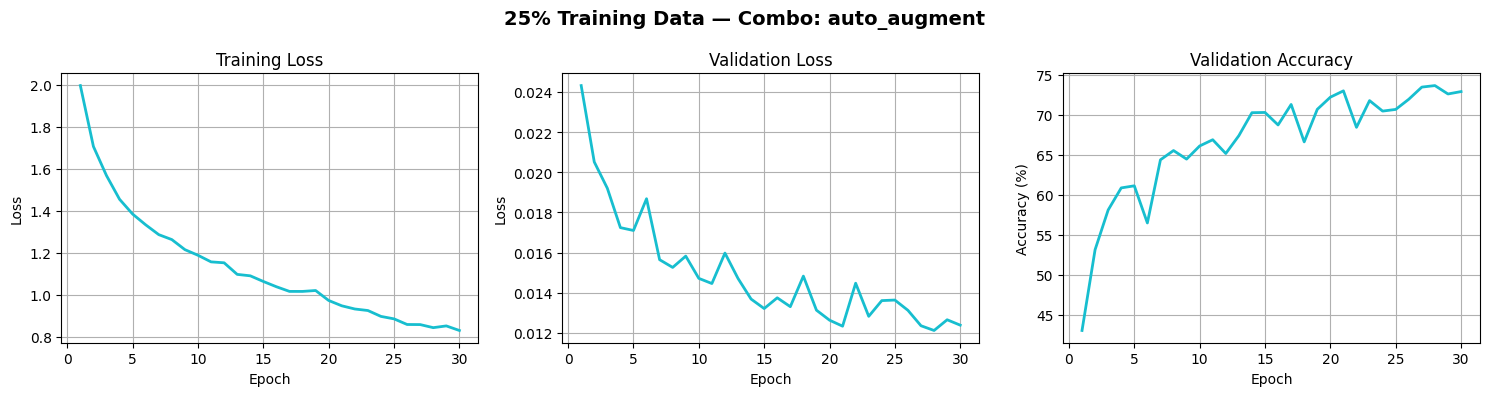


Experiment: 50% data, none
Training on 25000 images (50% of training data)
Testing on  10000 images (always full test set)
Train batches: 391
Test batches:  157
--- Training Started ---
Epoch [1/30], Train Loss: 1.5393, Val Loss: 0.0190, Val Accuracy: 55.42%
Epoch [2/30], Train Loss: 1.1687, Val Loss: 0.0169, Val Accuracy: 60.97%
Epoch [3/30], Train Loss: 1.0169, Val Loss: 0.0142, Val Accuracy: 68.09%
Epoch [4/30], Train Loss: 0.9144, Val Loss: 0.0136, Val Accuracy: 69.04%
Epoch [5/30], Train Loss: 0.8408, Val Loss: 0.0136, Val Accuracy: 69.56%
Epoch [6/30], Train Loss: 0.7672, Val Loss: 0.0143, Val Accuracy: 68.47%
Epoch [7/30], Train Loss: 0.7146, Val Loss: 0.0114, Val Accuracy: 74.94%
Epoch [8/30], Train Loss: 0.6624, Val Loss: 0.0116, Val Accuracy: 74.16%
Epoch [9/30], Train Loss: 0.6218, Val Loss: 0.0115, Val Accuracy: 74.62%
Epoch [10/30], Train Loss: 0.5644, Val Loss: 0.0117, Val Accuracy: 74.55%
Epoch [11/30], Train Loss: 0.5176, Val Loss: 0.0120, Val Accuracy: 73.99%
Epoch [1

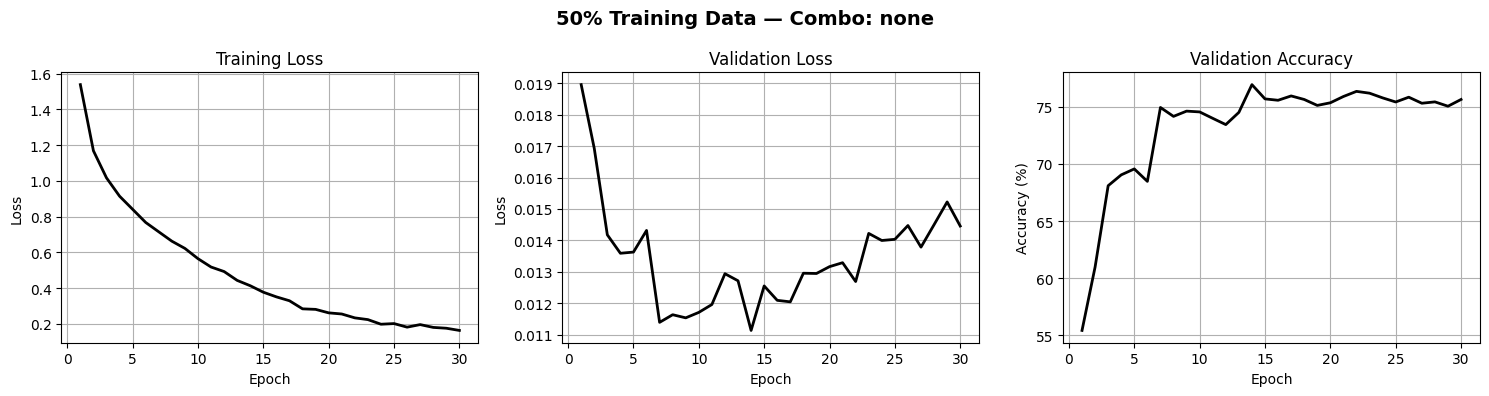


Experiment: 50% data, auto_augment
Training on 25000 images (50% of training data)
Testing on  10000 images (always full test set)
Train batches: 391
Test batches:  157
--- Training Started ---
Epoch [1/30], Train Loss: 1.8493, Val Loss: 0.0209, Val Accuracy: 51.72%
Epoch [2/30], Train Loss: 1.5374, Val Loss: 0.0178, Val Accuracy: 58.82%
Epoch [3/30], Train Loss: 1.4149, Val Loss: 0.0165, Val Accuracy: 62.06%
Epoch [4/30], Train Loss: 1.3366, Val Loss: 0.0153, Val Accuracy: 66.05%
Epoch [5/30], Train Loss: 1.2626, Val Loss: 0.0150, Val Accuracy: 66.81%
Epoch [6/30], Train Loss: 1.2156, Val Loss: 0.0141, Val Accuracy: 69.83%
Epoch [7/30], Train Loss: 1.1784, Val Loss: 0.0130, Val Accuracy: 70.71%
Epoch [8/30], Train Loss: 1.1436, Val Loss: 0.0141, Val Accuracy: 68.38%
Epoch [9/30], Train Loss: 1.1087, Val Loss: 0.0131, Val Accuracy: 70.70%
Epoch [10/30], Train Loss: 1.0873, Val Loss: 0.0131, Val Accuracy: 71.02%
Epoch [11/30], Train Loss: 1.0520, Val Loss: 0.0132, Val Accuracy: 70.70%


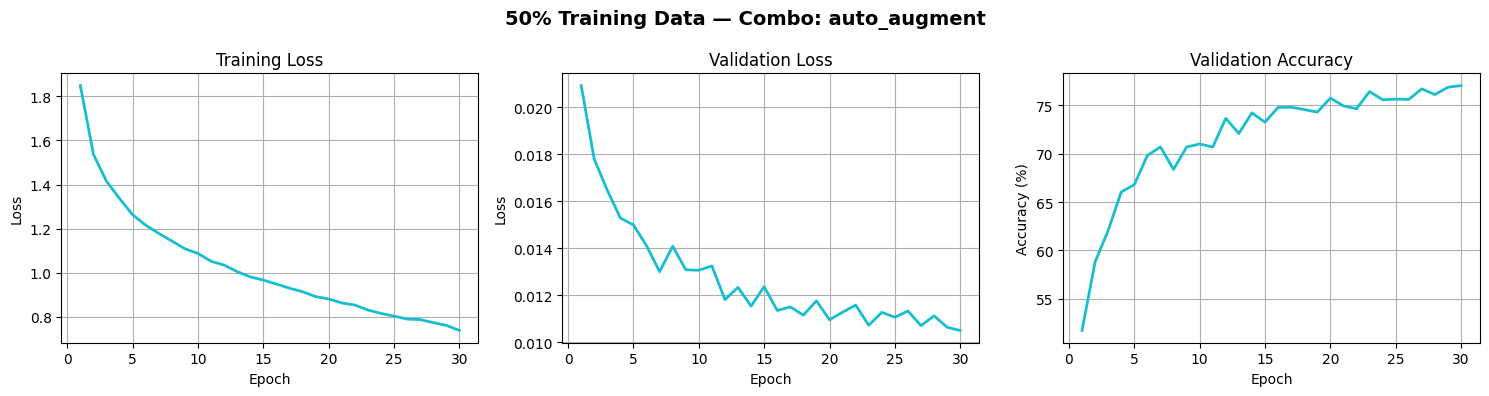


Experiment: 100% data, none
Training on 50000 images (100% of training data)
Testing on  10000 images (always full test set)
Train batches: 782
Test batches:  157
--- Training Started ---
Epoch [1/30], Train Loss: 1.3691, Val Loss: 0.0165, Val Accuracy: 63.31%
Epoch [2/30], Train Loss: 1.0142, Val Loss: 0.0138, Val Accuracy: 69.50%
Epoch [3/30], Train Loss: 0.8721, Val Loss: 0.0122, Val Accuracy: 72.36%
Epoch [4/30], Train Loss: 0.7758, Val Loss: 0.0118, Val Accuracy: 73.53%
Epoch [5/30], Train Loss: 0.7093, Val Loss: 0.0122, Val Accuracy: 73.32%
Epoch [6/30], Train Loss: 0.6547, Val Loss: 0.0103, Val Accuracy: 76.91%
Epoch [7/30], Train Loss: 0.6084, Val Loss: 0.0097, Val Accuracy: 78.47%
Epoch [8/30], Train Loss: 0.5666, Val Loss: 0.0101, Val Accuracy: 77.73%
Epoch [9/30], Train Loss: 0.5230, Val Loss: 0.0096, Val Accuracy: 78.68%
Epoch [10/30], Train Loss: 0.4928, Val Loss: 0.0107, Val Accuracy: 77.34%
Epoch [11/30], Train Loss: 0.4609, Val Loss: 0.0100, Val Accuracy: 78.47%
Epoch 

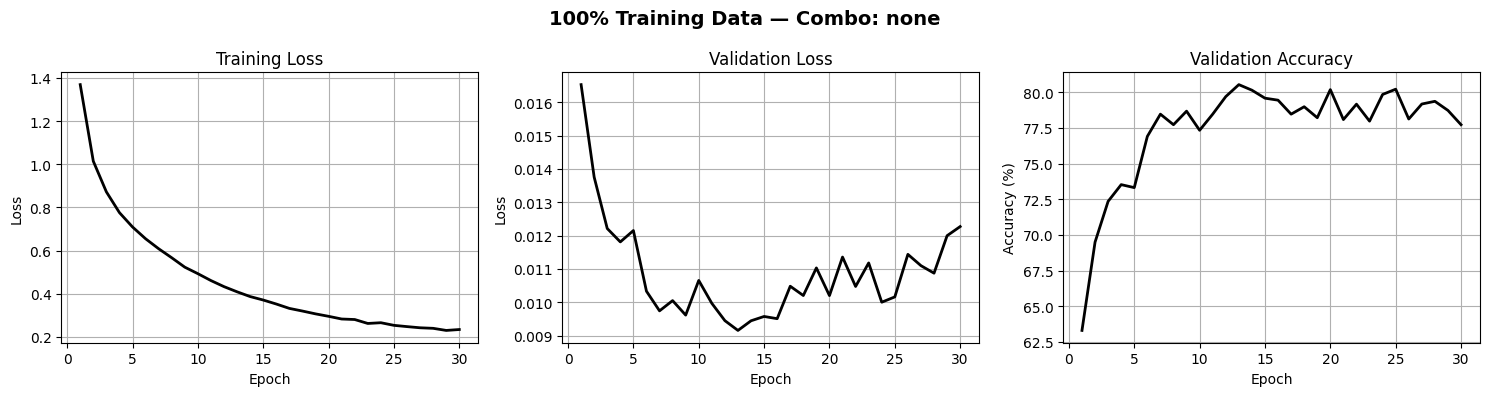


Experiment: 100% data, auto_augment
Training on 50000 images (100% of training data)
Testing on  10000 images (always full test set)
Train batches: 782
Test batches:  157
--- Training Started ---
Epoch [1/30], Train Loss: 1.7400, Val Loss: 0.0196, Val Accuracy: 55.42%
Epoch [2/30], Train Loss: 1.4048, Val Loss: 0.0155, Val Accuracy: 65.36%
Epoch [3/30], Train Loss: 1.2755, Val Loss: 0.0138, Val Accuracy: 68.26%
Epoch [4/30], Train Loss: 1.2009, Val Loss: 0.0140, Val Accuracy: 68.15%
Epoch [5/30], Train Loss: 1.1338, Val Loss: 0.0128, Val Accuracy: 71.24%
Epoch [6/30], Train Loss: 1.0908, Val Loss: 0.0115, Val Accuracy: 74.61%
Epoch [7/30], Train Loss: 1.0500, Val Loss: 0.0133, Val Accuracy: 70.50%
Epoch [8/30], Train Loss: 1.0164, Val Loss: 0.0110, Val Accuracy: 75.63%
Epoch [9/30], Train Loss: 0.9807, Val Loss: 0.0109, Val Accuracy: 75.62%
Epoch [10/30], Train Loss: 0.9519, Val Loss: 0.0116, Val Accuracy: 73.54%
Epoch [11/30], Train Loss: 0.9267, Val Loss: 0.0105, Val Accuracy: 76.96

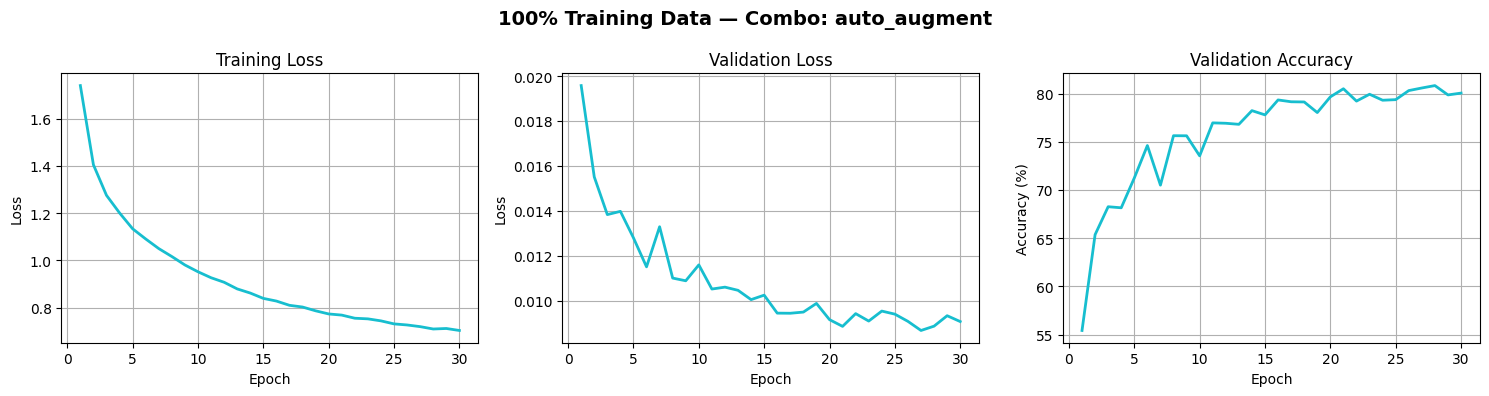

In [7]:
# _________________________________________
# RUN ALL EXPERIMENTS
# 4 percentages × N combinations = 4N
# _________________________________________
from plot_helper_functions import (plot_experiment,
                                   plot_bar_per_percentage,
                                   plot_final_summary,
                                   plot_all_combos_per_percentage
                                   )

# After running all experiments store metrics:
all_metrics = {} #train loss + validate loss + validate accuracy per epoch
all_results = {} #stores only best accuracy per experiment

os.makedirs('results', exist_ok=True)

for percentage in PERCENTAGES:
    for combination_name in COMBINATIONS:

        # Run experiment
        accuracy, metrics = run_experiment(percentage, combination_name)

        # Store results
        key = f"{int(percentage*100)}%_{combination_name}"
        all_results[key] = accuracy
        all_metrics[key] = metrics

        # Save to disk immediately
        with open(f'results/{key}.json', 'w') as f:
            json.dump({
                'train_losses': metrics[0],
                'val_losses': metrics[1],
                'val_accuracies': metrics[2],
                'best_accuracy': accuracy,
                'percentage': percentage,
                'combo': combination_name
            }, f, indent=2)
        print(f"Saved: results/{key}.json")

        # Plot this experiment's learning curves
        plot_experiment(metrics, percentage, combination_name)



Saved: plots/all_combos_10pct.png


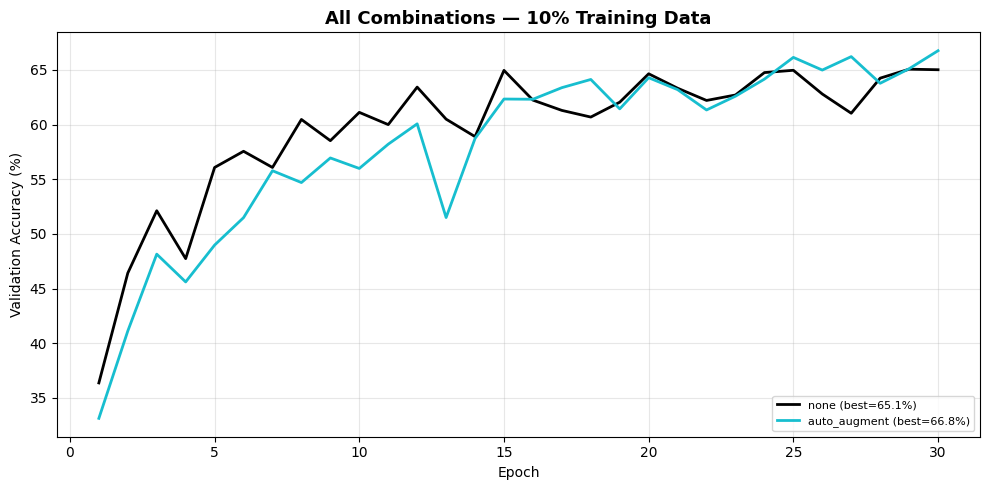

Saved: plots/all_combos_25pct.png


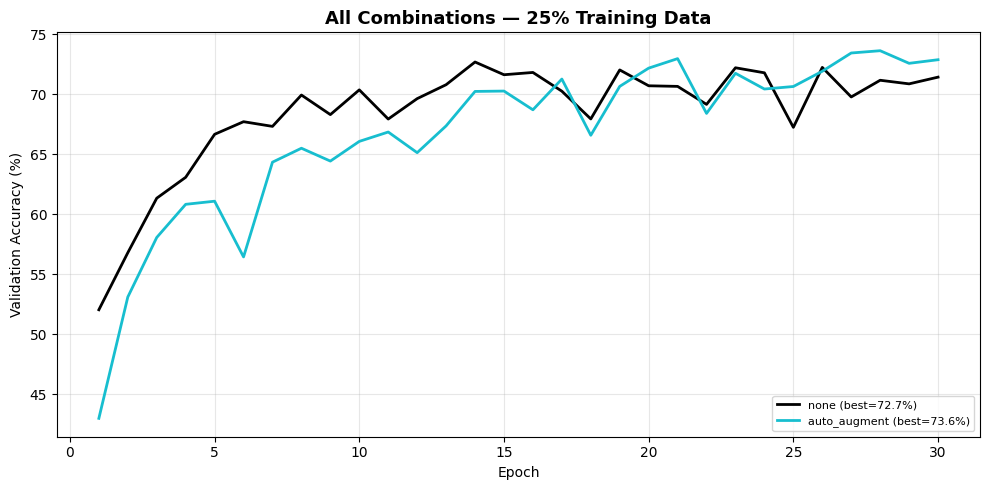

Saved: plots/all_combos_50pct.png


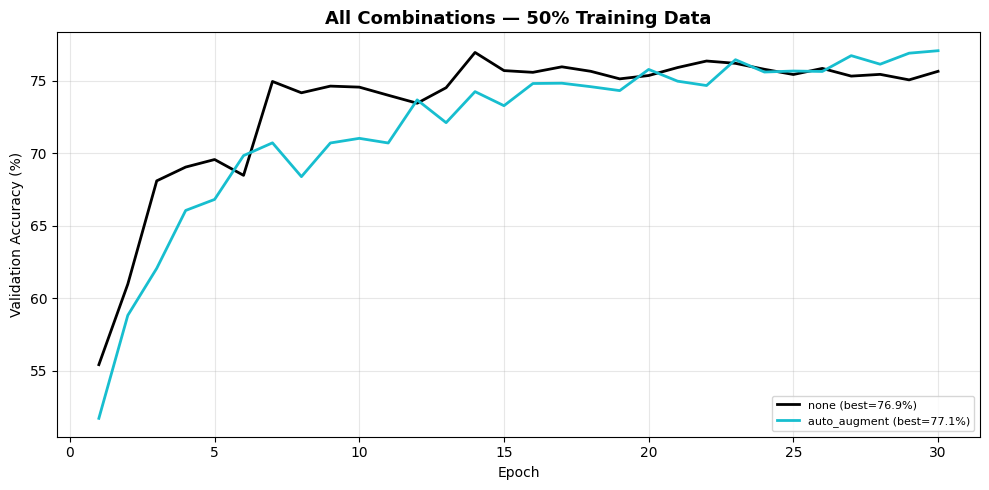

Saved: plots/all_combos_100pct.png


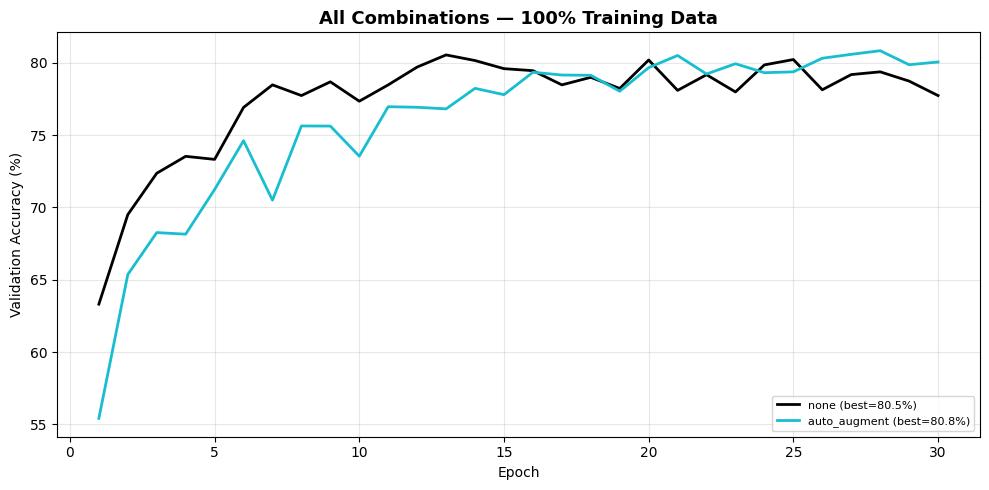

Saved: plots/bar_10pct.png


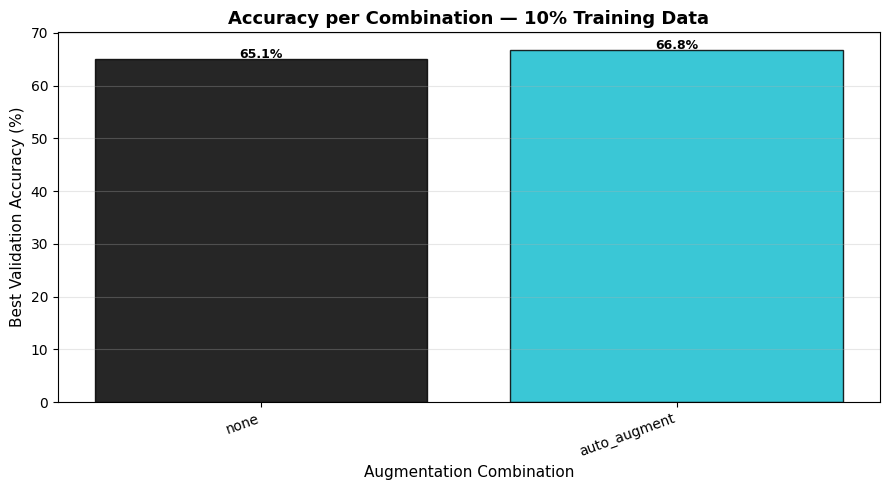

Saved: plots/bar_25pct.png


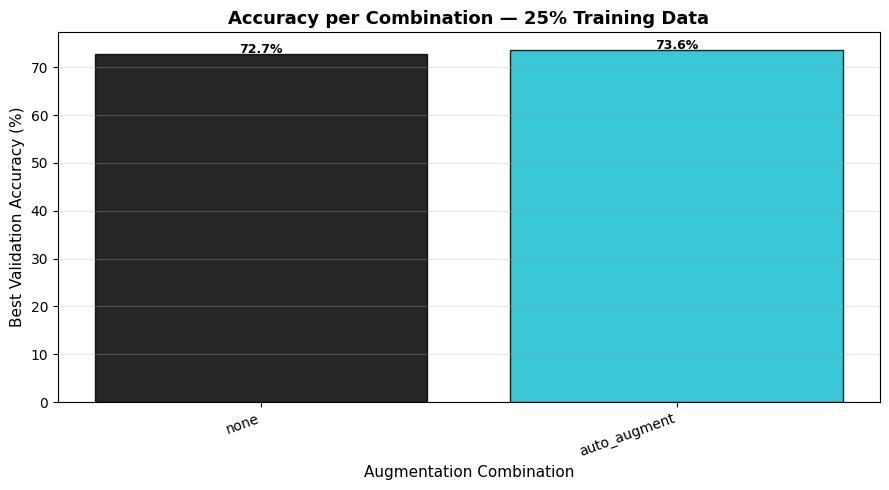

Saved: plots/bar_50pct.png


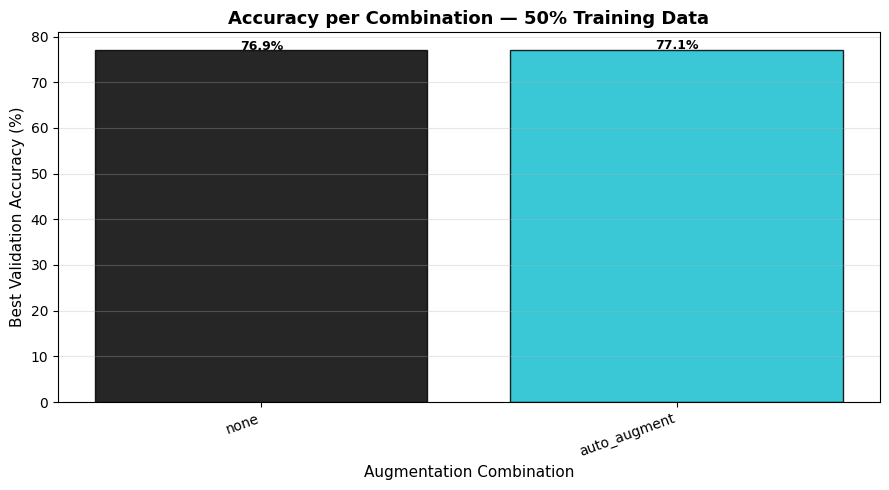

Saved: plots/bar_100pct.png


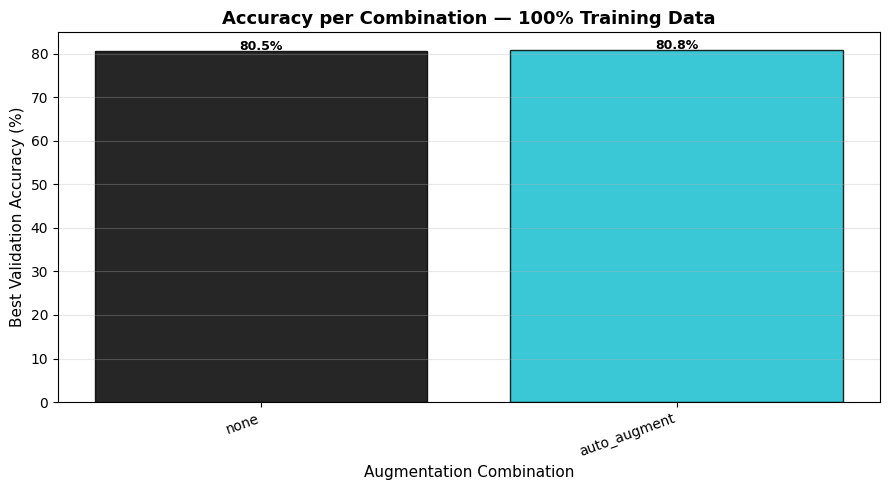

Saved: plots/final_summary.png


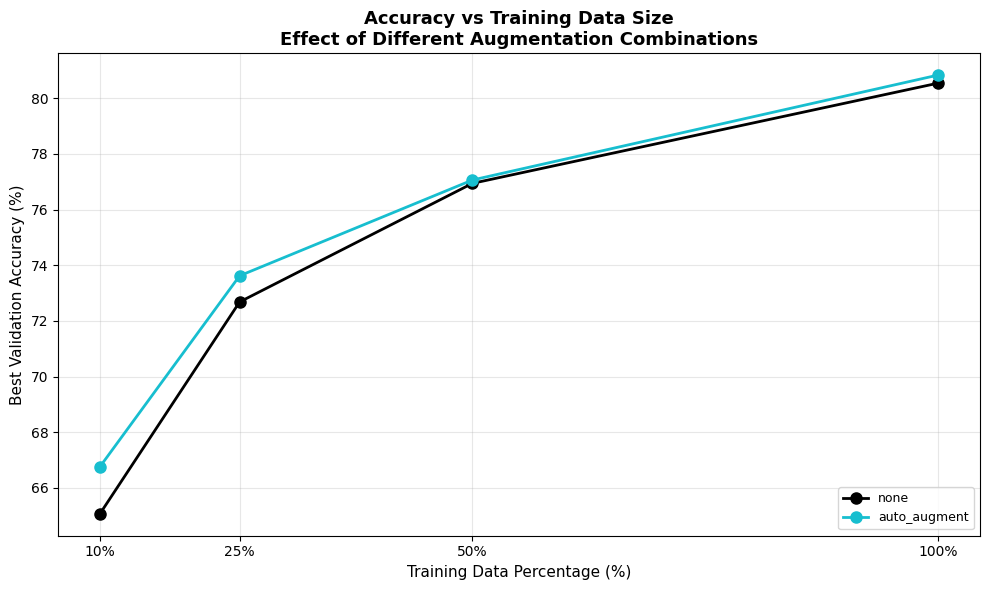

In [8]:
# _________________________________________
# PLOTS
# _________________________________________

# Plot 1: All 6 combos on same graph for each percentage (4 graphs)
plot_all_combos_per_percentage(
    all_metrics, all_results, PERCENTAGES, COMBINATIONS)

# Plot 2: Bar chart per percentage (4 bar charts)
plot_bar_per_percentage(all_results, PERCENTAGES, COMBINATIONS)

# Plot 3: THE main summary graph (1 graph, goes in report!)
# Plot the big final summary
#for all percentages (it will produce error if we didn't pass the 4 percentages[0.1, 0.25, 0.5, 1.0] experiments
#so comment this line if you will try one percentage only (e.g: 0.1)
plot_final_summary(all_results, PERCENTAGES, COMBINATIONS)



In [9]:
# _________________________________________
# PRINT FULL RESULTS TABLE
# _________________________________________
print("\n" + "=" * 55)
print("FULL RESULTS SUMMARY")
print("=" * 55)
print(f"{'Experiment':<35} {'Best Accuracy':>15}")
print("-" * 55)

for percentage in PERCENTAGES:
    p = int(percentage * 100)
    print(f"\n--- {p}% Training Data ---")
    for combo in COMBINATIONS:
        key = f"{p}%_{combo}"
        acc = all_results[key]
        print(f"  {combo:<33} {acc:>8.2f}%")

print("=" * 55)

# Save final summary table
with open('results/final_summary.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print("\nSaved: results/final_summary.json")


FULL RESULTS SUMMARY
Experiment                            Best Accuracy
-------------------------------------------------------

--- 10% Training Data ---
  none                                 65.07%
  auto_augment                         66.76%

--- 25% Training Data ---
  none                                 72.68%
  auto_augment                         73.62%

--- 50% Training Data ---
  none                                 76.94%
  auto_augment                         77.06%

--- 100% Training Data ---
  none                                 80.54%
  auto_augment                         80.83%

Saved: results/final_summary.json
